In [96]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import os

In [97]:
data_dir = './Task-1'
scene_image_path = os.path.join(data_dir, "img2.png")
sign_image_path = os.path.join(data_dir, "rh_sign.jpg")

scene_image = cv2.imread(scene_image_path)
sign_image = cv2.imread(sign_image_path)

In [98]:
def plot_images(images, titles=None, cols=3, figsize=(15, 10)):
    # Number of images
    num_images = len(images)
    
    # Calculate number of rows
    rows = math.ceil(num_images / cols)
    
    # Create the subplot grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.ravel()  # Flatten the 2D grid of axes to iterate over
    
    # Loop through each image and corresponding axis
    for i in range(rows * cols):
        if i < num_images:
            # Display image
            axes[i].imshow(images[i], cmap='gray' if len(images[i].shape) == 2 else None)
            
            # Add title if provided
            if titles:
                axes[i].set_title(titles[i], fontsize=12)
        else:
            # Hide any unused subplot
            axes[i].axis('off')
        
        # Remove axes for clarity
        axes[i].axis('off')
    
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

In [99]:
def red_color_thresholding(image):
    """Apply red color thresholding to detect red regions in the image."""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Define the range for detecting red color
    lower_red1 = np.array([0, 50, 50])      # Lower bound for the first red range
    upper_red1 = np.array([5, 255, 255])   # Upper bound for the first red range
    lower_red2 = np.array([165, 50, 50])   # Lower bound for the second red range
    upper_red2 = np.array([180, 255, 255]) # Upper bound for the second red range
    
    # Create masks for the red regions
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    
    # Combine the two masks
    mask = cv2.bitwise_or(mask1, mask2)
    
    return mask

def locate_rh_sign(sign_image, scene_image):
    """Detect all contours matching the reference sign and draw boxes around them."""

    # Convert images to grayscale
    source_gray = cv2.cvtColor(sign_image, cv2.COLOR_BGR2GRAY)
    target_gray = cv2.cvtColor(scene_image, cv2.COLOR_BGR2GRAY)

    debug_images = []
    debug_titles = []
    debug_images.append(scene_image.copy())
    debug_titles.append('Original')

    # Threshold the source and target images
    _, source_thresh = cv2.threshold(source_gray, 127, 255, cv2.THRESH_BINARY)
    _, target_thresh = cv2.threshold(target_gray, 127, 255, cv2.THRESH_BINARY)

    plot_images([source_thresh, target_thresh], ["Source", "Target"])

    # Initialize SIFT for keypoint detection and descriptor extraction
    orb = cv2.SIFT_create()

    # Detect keypoints and descriptors
    source_kp, source_des = orb.detectAndCompute(source_thresh, None)
    target_kp, target_des = orb.detectAndCompute(target_thresh, None)

    # Match descriptors using BFMatcher
    bf = cv2.BFMatcher()
    matches = bf.match(source_des, target_des)
    
    # Sort matches by distance (best matches first)
    matches = sorted(matches, key=lambda x: x.distance)[:10]

    # Extract the corresponding points
    source_pts = np.float32([source_kp[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    target_pts = np.float32([target_kp[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    # Find a homography to warp the reference sign onto the scene
    homography, mask_h = cv2.findHomography(source_pts, target_pts, cv2.RANSAC, 5.0)

    # Warp the reference mask onto the scene
    h, w = source_thresh.shape
    warped_mask = cv2.warpPerspective(source_thresh, homography, (target_gray.shape[1], target_gray.shape[0]))

    matched_img = cv2.drawMatches(sign_image, source_kp, scene_image, target_kp, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    plot_images([matched_img])
    # Threshold and find contours in the warped mask
    _, warped_thresh = cv2.threshold(warped_mask, 127, 255, cv2.THRESH_BINARY)
    # contours, _ = cv2.findContours(warped_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # # Find the reference contour
    # ref_contour, _ = cv2.findContours(source_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # ref_contour = ref_contour[0] if ref_contour else None

    result_image = scene_image.copy()

    # # Iterate through all detected contours and draw boxes
    # for contour in contours:
    #     if ref_contour is not None:
    #         score = cv2.matchShapes(ref_contour, contour, cv2.CONTOURS_MATCH_I1, 0.0)
    #         print(f"Matching Score: {score}")

    #     # Draw a bounding box around each detected contour
    #     x, y, w, h = cv2.boundingRect(contour)
    #     cv2.rectangle(result_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Debugging: Add result image to debug list
    debug_images.append(result_image)
    debug_titles.append("All Detected RH Sign Contours")

    # Display debug images
    plot_images(debug_images, debug_titles)

    # return result_image, contours



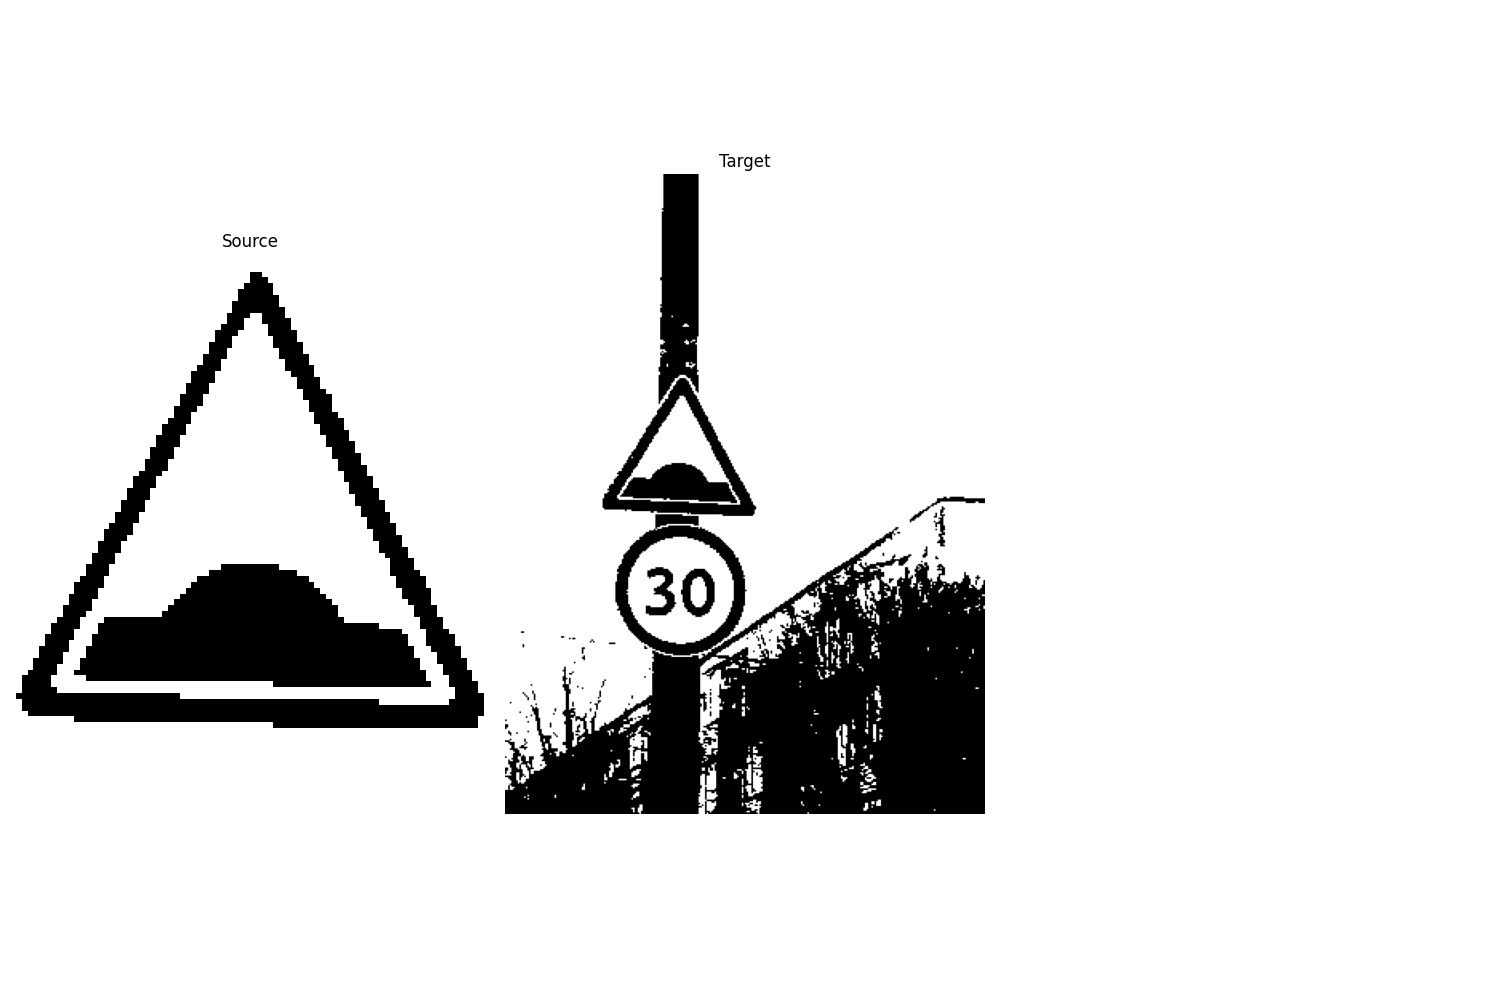

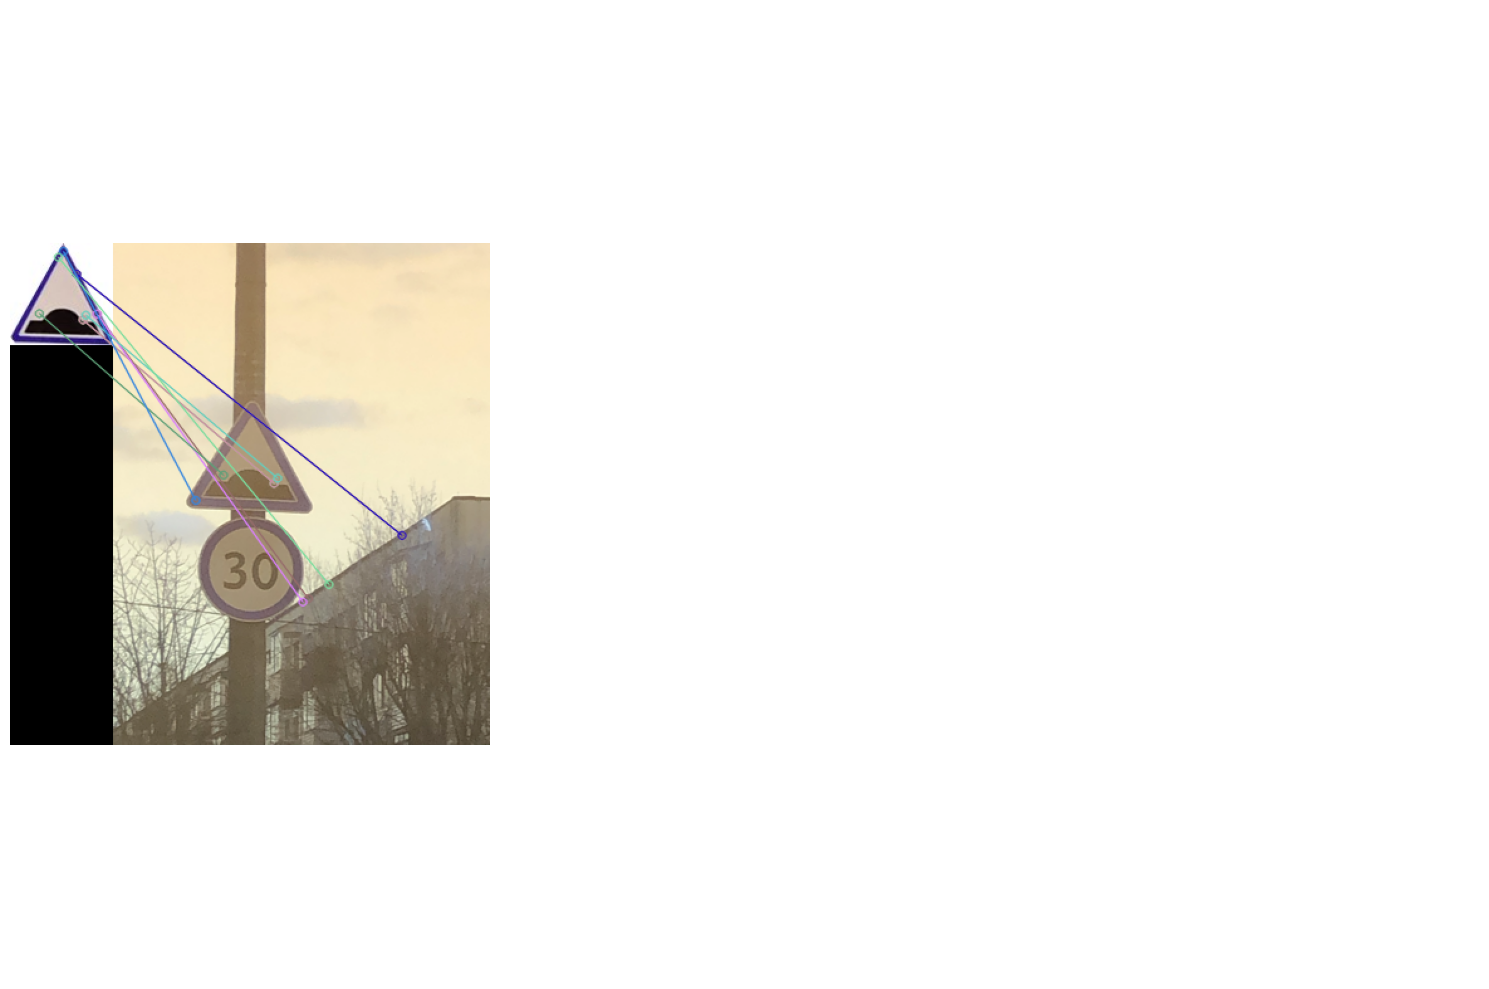

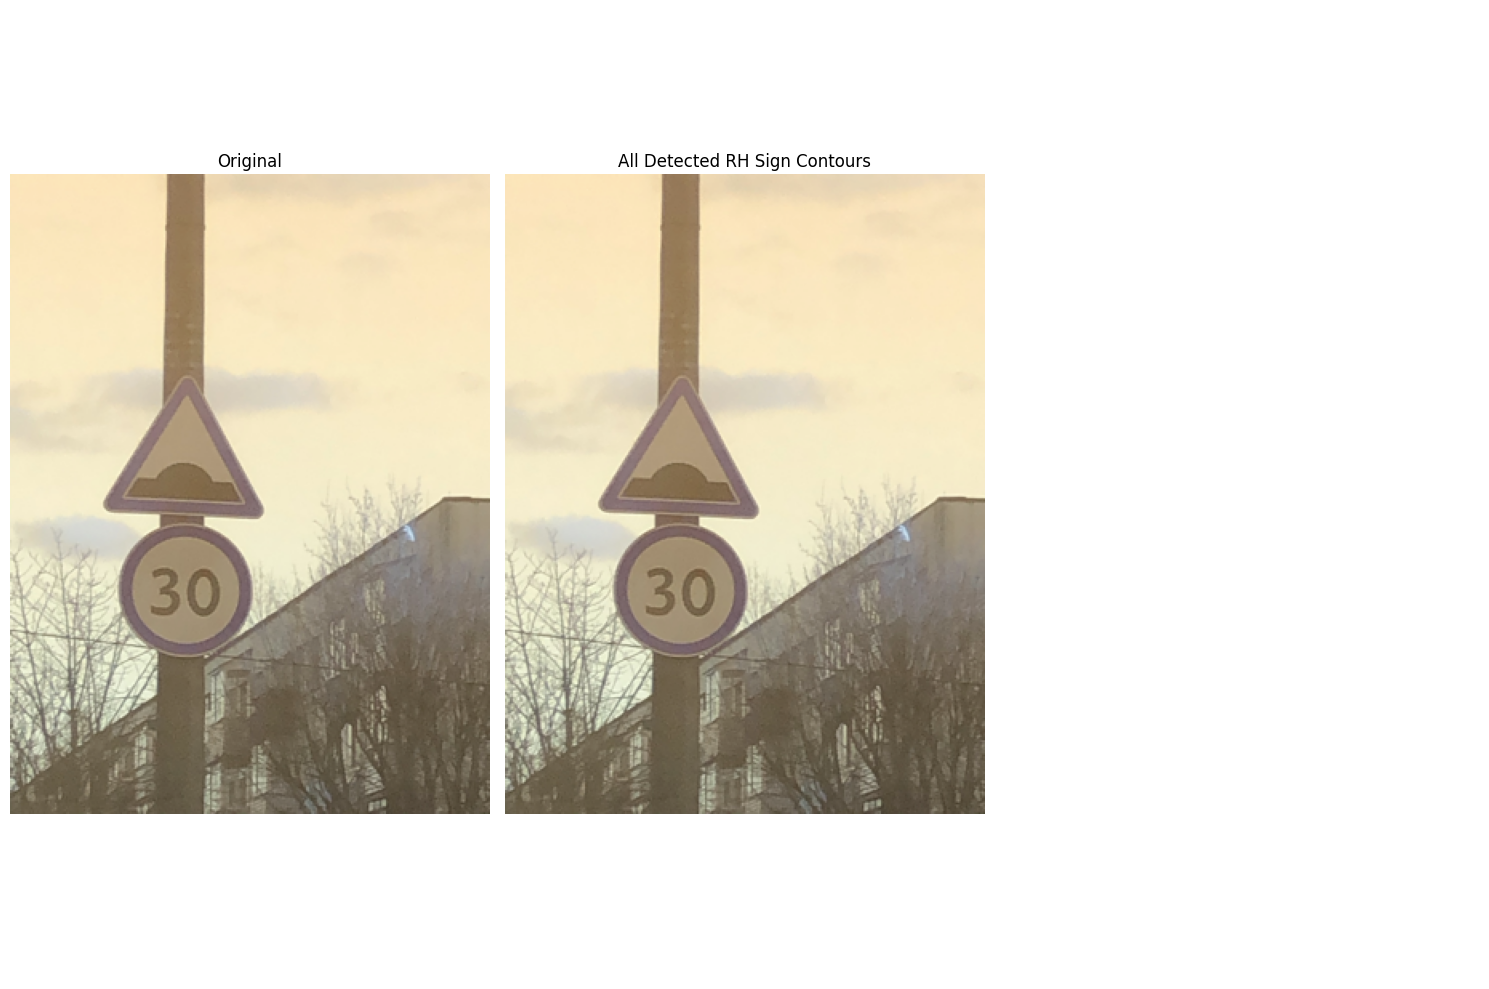

In [100]:
locate_rh_sign(sign_image, scene_image)